In [1]:
import pandas as pd
import numpy as np

# default пути и значения

In [3]:
from pathlib import Path
import os

PROJECT_ROOT = Path(os.path.curdir)
print(f"Project ROOT dir = {PROJECT_ROOT}")

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
REPORTS_DIR = OUTPUT_DIR / "reports"

RAW_DATA_PATH = DATA_DIR / "input_data.xlsx"
COLUMNS_FILE = DATA_DIR / "columns.txt"

# артефакты
CLEAN_DATA_PATH = OUTPUT_DIR / "data_clean.csv"
FE_FULL_PATH = OUTPUT_DIR / "data_fe_full.csv"
DATA_FOR_MODEL_PATH = OUTPUT_DIR / "indata_processed.csv"
FE_ONLY_PATH = OUTPUT_DIR / "fe_features.csv"
DROPPED_FEATURES_PATH = OUTPUT_DIR / "dropped_features.csv"

INDEX_COL = "Unnamed: 0"

IC50_COL = "IC50, mM"
CC50_COL = "CC50, mM"
SI_COL = "SI"

TARGET_COLS = [IC50_COL, CC50_COL, SI_COL]

# производные целевые
PIC50_COL = "pIC50"
PCC50_COL = "pCC50"
LOG_SI_COL = "log1p_SI"

# воспроизводимость
RANDOM_STATE = 42

# параметры очистки данных
VAR_TS = 0.01
CORR_TS = 0.9
SI_TOLERANCE_REL = 1e-6

# Lipinski / Veber
LIPINSKI_MW = 500
LIPINSKI_LOGP = 5
LIPINSKI_HDB = 5
LIPINSKI_HBA = 10
VEBER_ROT_BONDS = 10
VEBER_TPSA = 140

# отбор признаков
RF_IMPORTANCE_TOP_N = 30
OUTLIER_IQR_SCALE = 1.7
OUTLIER_PCT_LOG_TRANSF = 10.0

# VSA: число бинов по префиксам
VSA_BIN_CNT = {
    "PEOE_VSA": 14,
    "SMR_VSA": 10,
    "SlogP_VSA": 12,
    "EState_VSA": 11,
    "VSA_EState": 10
}

Project ROOT dir = .


# загрузка данных

In [4]:
def load_raw_data(path=None):
    path = path or RAW_DATA_PATH
    if not path.exists():
        raise FileNotFoundError(f"Нет файла данных {path}")
    return pd.read_excel(str(path))


def save_columns_list(df: pd.DataFrame, path=None):
    path = path or COLUMNS_FILE
    if path.exists():
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text("\n".join(df.columns.astype(str)), encoding='utf-8')

In [5]:
# загружаем данные
raw_df = load_raw_data()

# сохраняем названия столбцов
save_columns_list(raw_df)

# выводим общую информацию
raw_df.describe()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000
mean,500.000000,222.805156,589.110728,72.508823,10.831637,10.831637,0.180681,-0.967237,0.580412,29.487989,...,0.053946,0.011988,0.008991,0.000999,0.000999,0.051948,0.0,0.069930,0.204795,0.006993
std,289.108111,402.169734,642.867508,684.482739,3.307505,3.307505,0.168710,1.588036,0.212230,12.742749,...,0.259011,0.108886,0.094441,0.031607,0.031607,0.222033,0.0,0.255157,1.215326,0.083373
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,250.000000,12.515396,99.999036,1.433333,9.252350,9.252350,0.051073,-1.334487,0.442842,18.486486,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,500.000000,46.585183,411.039342,3.846154,12.179236,12.179236,0.124606,-0.419485,0.634981,29.290323,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,750.000000,224.975928,894.089176,16.566667,13.167843,13.167843,0.291020,0.061754,0.742483,38.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,1000.000000,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


Исходя из информации в открытых источниках SI = CC50 / IC50  
Сразу сделаем проверку  
- вычисляем отношение из данных датасета
- считаем относительную ошибку
- сохраняем метрики
- - максимум относительной ошибки
- - среднее относительной ошибки
- - проверяем на не превышение порога макисмальной ошибки
- - считаем количество нулевых значений IC50  

Создаем преобразованные целевые значения
- для IC50, CC50 - -log10(значение в Молль)
- для SI - log1p

In [6]:
def validate_si(df: pd.DataFrame):
    ic50 = df[IC50_COL].astype(float)
    cc50 = df[CC50_COL].astype(float)
    si_inp = df[SI_COL].astype(float)
    si_calc = cc50 / ic50
    rel_err = (si_calc - si_inp).abs() / (si_inp.abs() + 1e-12)
    return {
        "max_relative_error": float(rel_err.max()),
        "mean_relative_error": float(rel_err.mean()),
        "is_tolerance_ok": bool(rel_err.max() < SI_TOLERANCE_REL),
        "n_zero_ic50": int((ic50 == 0).sum())
    }

def add_target_transforms(df: pd.DataFrame):
    res = df.copy()
    for raw_col, new_col in ((IC50_COL, PIC50_COL), (CC50_COL, PCC50_COL)):
        c_mol = res[raw_col].astype(float) * 1e-3
        c_mol = c_mol.clip(lower=1e-12)
        res[new_col] = -np.log10(c_mol)
    res[LOG_SI_COL] = np.log1p(res[SI_COL].astype(float))
    return res


# разделение на признаки и целевые значения
def split_xy(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    work = df.drop([INDEX_COL], axis=1) if INDEX_COL in df.columns else df.copy()
    y = work[TARGET_COLS].copy()
    x = work.drop(TARGET_COLS, axis=1)
    return x, y

In [7]:
si_check = validate_si(raw_df)
df = add_target_transforms(raw_df.drop([INDEX_COL], axis=1))

# проводим анализ данных через построение графиков

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# гистограммы сырых и преобразованных целевых значений
def plot_target_distr(df: pd.DataFrame):
    pairs = [
        (IC50_COL, PIC50_COL),
        (CC50_COL, PCC50_COL),
        (SI_COL, LOG_SI_COL)
    ]
    _, axes = plt.subplots(len(pairs), 2, figsize=(10,9))
    for i, (raw, trans) in enumerate(pairs):
        if raw not in df.columns:
            continue
        axes[i, 0].hist(df[raw].dropna(), bins=40, color="blue", edgecolor="white")
        axes[i, 0].set_title(raw)
        if trans in df.columns:
            axes[i, 1].hist(df[trans].dropna(), bins=40, color="coral", edgecolor="white")
            axes[i, 1].set_title(trans)
    plt.tight_layout()
    plt.show()
    return


# связь IC50 / CC50 / SI
def plot_target_scatter(df: pd.DataFrame):
    _, axes = plt.subplots(1, 3, figsize=(14, 4))
    if IC50_COL in df.columns and CC50_COL in df.columns:
        axes[0].scatter(df[IC50_COL], df[CC50_COL], alpha=0.4, s=12)
        axes[0].set_xlabel("IC50")
        axes[0].set_ylabel("CC50")
    if IC50_COL in df.columns and SI_COL in df.columns:
        x = df[IC50_COL]
        axes[1].scatter(x, df[SI_COL], alpha=0.4, s=12)
        axes[1].set_xlabel("ингибирующая конц.")
        axes[1].set_ylabel(SI_COL)
    if CC50_COL in df.columns and SI_COL in df.columns:
        x = df[CC50_COL]
        axes[2].scatter(x, df[SI_COL], alpha=0.4, s=12)
        axes[2].set_xlabel("цитотоксическая конц.")
        axes[2].set_ylabel(SI_COL)
    plt.tight_layout()
    plt.show()
    return


# Диаграмма Lipinski в полярной системе координат
def plot_lipinski_radar(df: pd.DataFrame, n_examples: int = 3):
    params_need = ["MolWt", "MolLogP", "NumHDonors", "NumHAcceptors"]
    if not all(c in df.columns for c in params_need) or SI_COL not in df.columns:
        return
    
    def lipinski_norm(row):
        return [
            min(row["MolWt"] / LIPINSKI_MW, 1.5),
            min(row["MolLogP"] / LIPINSKI_LOGP, 1.5),
            min(row["NumHDonors"] / LIPINSKI_HDB, 1.5),
            min(row["NumHAcceptors"] / LIPINSKI_HBA, 1.5)
        ]
    
    labels = ["MW/500", "LogP/5", "HBD/5", "HBA/10"]
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint = False).tolist()
    angles += angles[:1]

    top = df.nlargest(n_examples, SI_COL)
    bottom = df.nsmallest(n_examples, SI_COL)

    _, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    for _, row in top.iterrows():
        vals = lipinski_norm(row) + [lipinski_norm(row)[0]]
        ax.plot(angles, vals, label=f"high SI={row[SI_COL]:.1f}")
    for _, row in bottom.iterrows():
        vals = lipinski_norm(row) + [lipinski_norm(row)[0]]
        ax.plot(angles, vals, linestyle='--', label=f"low SI={row[SI_COL]:.2f}")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.set_title("Профиль Lipinski (high vs low SI)")
    plt.tight_layout()
    plt.show()
    return


# PCA по признакам
def plot_pca_targets(df: pd.DataFrame, max_features: int = 80):
    x, _ = split_xy(df)
    if len(x.columns) > max_features:
        x = x[x.columns[:max_features]]
    x_scaled = StandardScaler().fit_transform(x.fillna(x.median()))
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    xy = pca.fit_transform(x_scaled)

    _, ax = plt.subplots(figsize=(8,6))
    c = df[SI_COL].values if SI_COL in df.columns else np.zeros(len(df))
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=c, cmap="viridis", alpha=0.6, s=15)
    plt.colorbar(sc, label=SI_COL)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title("PCA")
    plt.tight_layout()
    plt.show()
    return


# взаимная корреляция по признакам
def plot_corr_heatmap(df: pd.DataFrame, max_cols: int = 40):
    x, _ = split_xy(df)
    if len(x.columns) > max_cols:
        v = x.var().sort_values(ascending=False)
        x = x[v.head(max_cols).index]
    corr = x.corr()
    _, ax = plt.subplots(figsize=(12,10))
    sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax, xticklabels=True, yticklabels=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_title(f"Корреляция (top {len(x.columns)} by var)")
    plt.tight_layout()
    plt.show()
    return

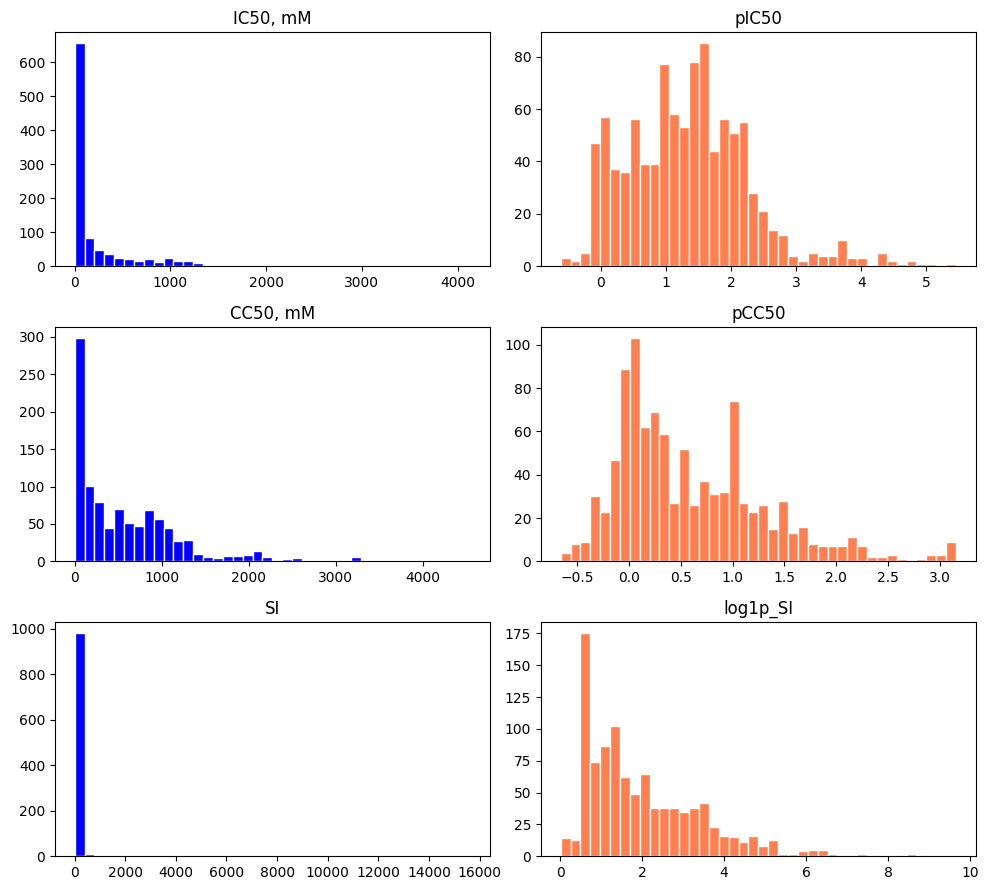

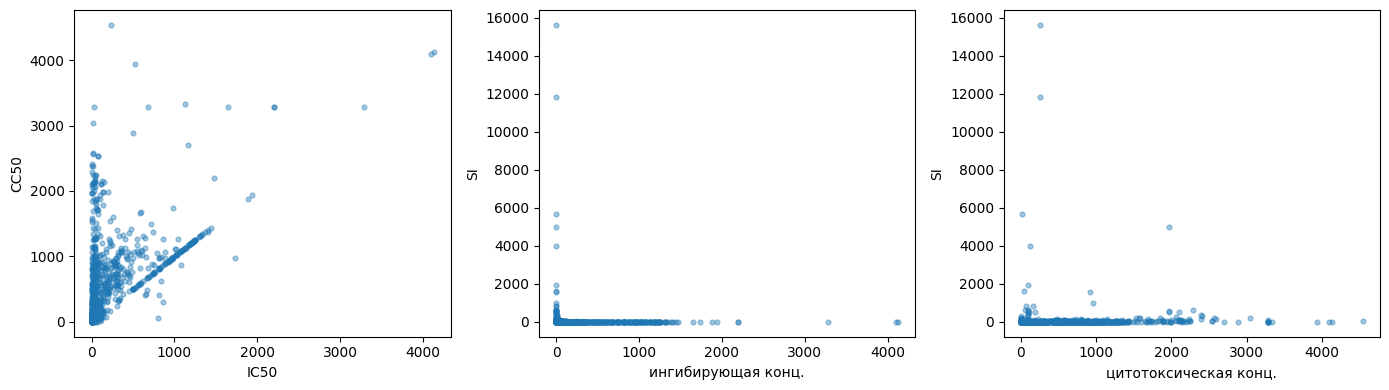

In [9]:
plot_target_distr(df)
plot_target_scatter(df)

# очистка

In [10]:
from sklearn.feature_selection import VarianceThreshold


# находим столбца - константы
def find_constant_cols(x: pd.DataFrame) -> list[str]:
    return [c for c in x.columns if x[c].nunique(dropna=False) <= 1]


# формируем отчет по столцам с nan значениями
# имя + процент nan значений
def find_nan_cols(x: pd.DataFrame) -> list[tuple[str, float]]:
    n = len(x)
    res = []
    for col in x.columns:
        n_nan = int(x[col].isna().sum())
        if n_nan > 0:
            res.append((col, 100 * n_nan / n))
    return res


# полный протокол очистки данных
def clean_features(df: pd.DataFrame, var_ts: float = VAR_TS, drop_nan_rows = True):
    x, y = split_xy(df)

    const_features = find_constant_cols(x)
    if const_features:
        x = x.drop(const_features, axis=1)

    nan_features = find_nan_cols(x)
    if drop_nan_rows and nan_features:
        mask = x.index.to_list()
        comb = pd.concat([x, y], axis=1)
        comb_cl = comb.dropna(axis=0)
        dropped_ridxs = [i for i in mask if i not in comb_cl.index]
        x = comb_cl.drop(TARGET_COLS, axis=1)
        y = comb_cl[TARGET_COLS]

    if len(x.columns) > 0:
        selector = VarianceThreshold(threshold=var_ts)
        x_arr = selector.fit_transform(x)
        good = x.columns[selector.get_support()].tolist()
        low_var_features = [c for c in x.columns if c not in good]
        x = pd.DataFrame(x_arr, index=x.index, columns=good)

    # контроль
    for t in TARGET_COLS:
        if t not in y.columns:
            raise ValueError(f"При очистке удален целевой столбец {t}")
        
    res = pd.concat([y, x], axis=1)
    return res, {
        "constant_features": const_features,
        "nan_features": nan_features,
        "dropped_indexes": dropped_ridxs,
        "low_variance_features": low_var_features,
        "n_rows_final": len(res)
    }

In [11]:
df_clean, report = clean_features(df)
print("\nОтчёт по результатм очистки данных")
for label, value in report.items():
    if isinstance(value, list):
        print(f"\t{label} ({len(value)}):")
        for v in value:
            if isinstance(v, tuple):
                print(f"\t\t{v[0]}: {v[1]:.2f}")
            else:
                print(f"\t\t{v}")
    else:
        print(f"\t{label}: {value}")


Отчёт по результатм очистки данных
	constant_features (18):
		NumRadicalElectrons
		SMR_VSA8
		SlogP_VSA9
		fr_N_O
		fr_SH
		fr_azide
		fr_barbitur
		fr_benzodiazepine
		fr_diazo
		fr_dihydropyridine
		fr_isocyan
		fr_isothiocyan
		fr_lactam
		fr_nitroso
		fr_phos_acid
		fr_phos_ester
		fr_prisulfonamd
		fr_thiocyan
	nan_features (12):
		MaxPartialCharge: 0.30
		MinPartialCharge: 0.30
		MaxAbsPartialCharge: 0.30
		MinAbsPartialCharge: 0.30
		BCUT2D_MWHI: 0.30
		BCUT2D_MWLOW: 0.30
		BCUT2D_CHGHI: 0.30
		BCUT2D_CHGLO: 0.30
		BCUT2D_LOGPHI: 0.30
		BCUT2D_LOGPLOW: 0.30
		BCUT2D_MRHI: 0.30
		BCUT2D_MRLOW: 0.30
	dropped_indexes (3):
		78
		79
		80
	low_variance_features (16):
		MinPartialCharge
		MaxAbsPartialCharge
		fr_Ar_COO
		fr_HOCCN
		fr_aldehyde
		fr_amidine
		fr_azo
		fr_epoxide
		fr_guanido
		fr_hdrzine
		fr_nitrile
		fr_oxazole
		fr_sulfone
		fr_term_acetylene
		fr_tetrazole
		fr_urea
	n_rows_final: 998


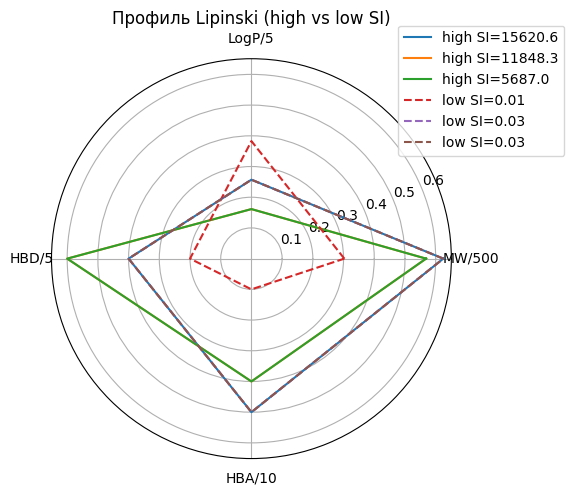

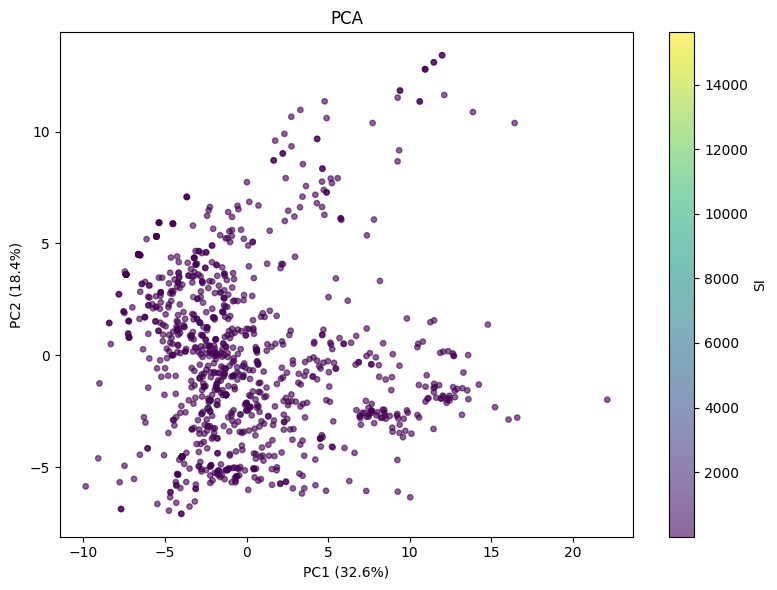

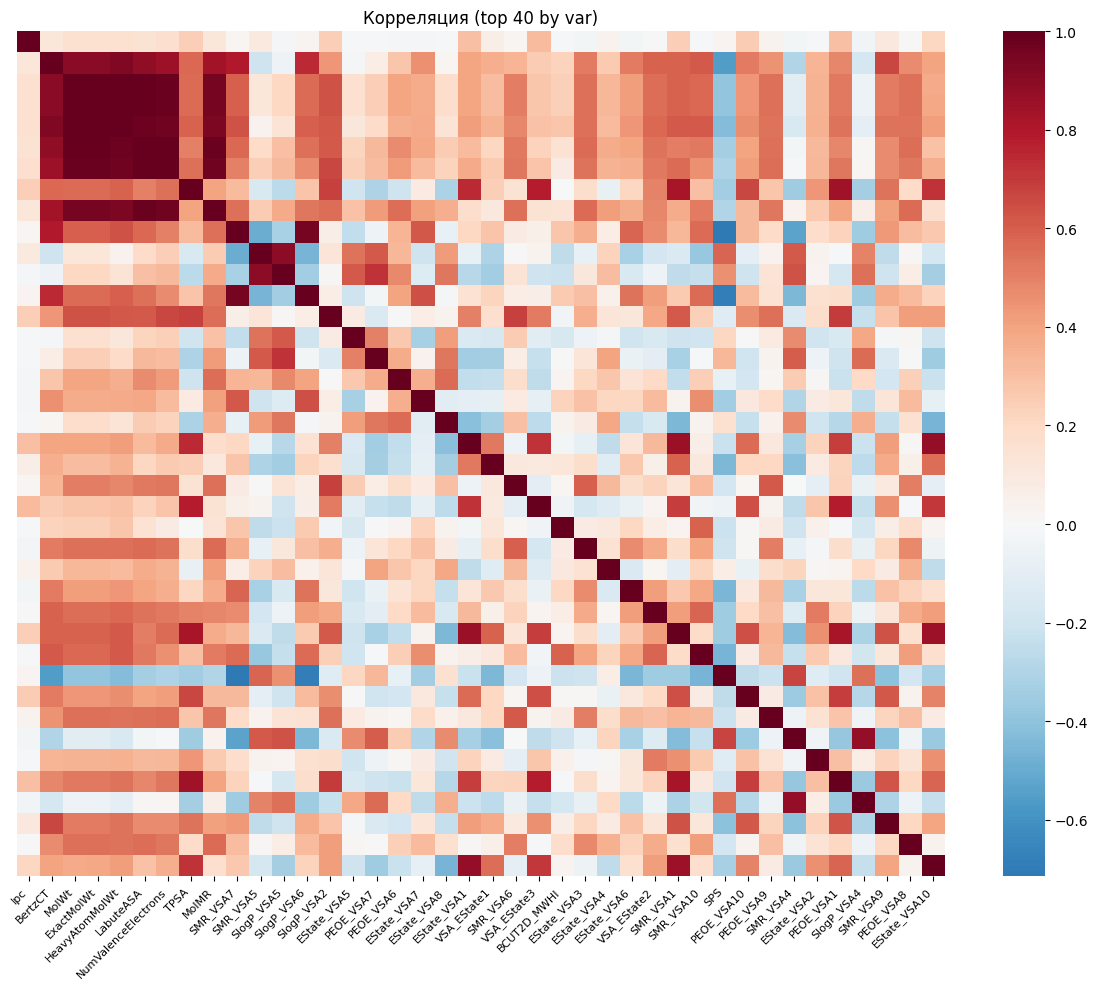

In [12]:
plot_lipinski_radar(df_clean)
plot_pca_targets(df_clean)
plot_corr_heatmap(df_clean)

# Feature engineering
## Создание новых признаков

In [13]:
# считаем нормированную энтропию по строке
def entropy_row(values: np.ndarray, n_bins: int) -> np.ndarray:
    v = np.clip(values.astype(float), 0, None)
    row_sum = v.sum(axis=1, keepdims=True)
    probs = np.divide(v, row_sum + 1e-12)
    ent = -np.sum(probs * np.log(probs + 1e-12), axis=1)
    return ent / np.log(n_bins)


# создаём агрегированные свойства VSA: Total, Max, Min, Entropy
def extract_vsa_stats(df: pd.DataFrame, prefix: str, n_bins: int) -> pd.DataFrame:
    cols = sorted(
        [c for c in df.columns if c.startswith(prefix)],
        key= lambda x: int("".join(filter(str.isdigit, x)) or 0)
    )
    if len(cols) != n_bins:
        return pd.DataFrame(index=df.index)
    
    block = df[cols].astype(float)
    return pd.DataFrame({
        f"{prefix}_Total": block.sum(axis=1),
        f"{prefix}_Max": block.max(axis=1),
        f"{prefix}_Min": block.min(axis=1),
        f"{prefix}_Entropy": entropy_row(block.values, n_bins)
    }, index=df.index)


# в соответсвии с best practices из открытых источников создаем новые признаки
def feature_eng(df: pd.DataFrame) -> pd.DataFrame:
    x, y = split_xy(df)
    fe = pd.DataFrame(index=df.index)

    # 1. Плотность / гибкость
    fe["PackingDensity"] = x["HeavyAtomCount"] / x["LabuteASA"].clip(lower=1e-6)
    fe["MassDensity"] = x["MolWt"] / x["LabuteASA"].clip(lower=1e-6)
    fe["FlexibilityPerMass"] = x["NumRotatableBonds"] / x["MolWt"].clip(lower=1e-6)
    fe["FlexibilityPerRing"] = x["NumRotatableBonds"] / (x["RingCount"] + 1)

    # 2. Гибридизация
    fe["Sp2Fraction"] = 1 - x["FractionCSP3"]
    fe["Sp3toSp2Ratio"] = x["FractionCSP3"] / (fe["Sp2Fraction"] + 1e-6)

    # 3. Ароматичность
    fe["AromaticToAliphaticRatio"] = (x["NumAromaticRings"] + 1) / (
        x["NumAliphaticRings"] + 1
    )
    fe["AromaticFraction"] = x["NumAromaticRings"] / (x["RingCount"] + 1)

    # 4. Drug-likeness
    fe["DrugScore"] = x["qed"] * (1 - (x["MolLogP"] - 2.5).abs() / 10)

    # 5. VSA полярность (эвристика по номерам бинов PEOE)
    polar = [c for c in x.columns if c.startswith("PEOE_VSA")]
    polar_hi = [
        c for c in polar if int("".join(ch for ch in c if ch.isdigit()) or "0") >= 7
    ]
    polar_lo = [
        c for c in polar if int("".join(ch for ch in c if ch.isdigit()) or "0") <= 6
    ]
    if polar_hi and polar_lo:
        fe["PolarVSATotal"] = x[polar_hi].sum(axis=1)
        fe["NonpolarVSATotal"] = x[polar_lo].sum(axis=1)
        fe["PolarityRatio"] = fe["PolarVSATotal"] / (fe["NonpolarVSATotal"] + 1e-6)

    fe["TPSAperMass"] = x["TPSA"] / x["MolWt"].clip(lower=1e-6)
    fe["TPSAperHeavyAtom"] = x["TPSA"] / x["HeavyAtomCount"].clip(lower=1)

    fe["HBDplusHBA"] = x["NumHDonors"] + x["NumHAcceptors"]
    fe["HBDtoHBARatio"] = x["NumHDonors"] / (x["NumHAcceptors"] + 1e-6)

    # Lipinski / Veber
    fe["LipinskiViolations"] = (
        (x["MolWt"] > 500).astype(int)
        + (x["MolLogP"] > 5).astype(int)
        + (x["NumHDonors"] > 5).astype(int)
        + (x["NumHAcceptors"] > 10).astype(int)
    )
    fe["LipinskiScore"] = (
        np.clip(1 - (x["MolWt"] - 500) / 500, 0, 1)
        * np.clip(1 - (x["MolLogP"] - 5) / 5, 0, 1)
        * np.clip(1 - (x["NumHDonors"] - 5) / 5, 0, 1)
        * np.clip(1 - (x["NumHAcceptors"] - 10) / 10, 0, 1)
    )
    fe["VeberPass"] = (
        (x["NumRotatableBonds"] <= 10) & (x["TPSA"] <= 140)
    ).astype(int)

    # Chi / Kappa / BCUT
    chi_cols = [c for c in x.columns if c.startswith("Chi")]
    if chi_cols:
        chi = x[chi_cols]
        fe["ChiSum"] = chi.sum(axis=1)
        fe["ChiMean"] = chi.mean(axis=1)
        fe["ChiRange"] = chi.max(axis=1) - chi.min(axis=1)

    fe["BalabanNormalized"] = x["BalabanJ"] / np.log(x["HeavyAtomCount"] + 1)
    fe["KappaShape"] = x["Kappa1"] / (x["Kappa2"] + 1e-6)
    fe["KappaCyclicity"] = x["Kappa3"] / (x["Kappa1"] + 1e-6)
    fe["HallKierPerHeavyAtom"] = x["HallKierAlpha"] / (x["HeavyAtomCount"] + 1)

    bcut_pairs = {
        "MW": ("BCUT2D_MWHI", "BCUT2D_MWLOW"),
        "Charge": ("BCUT2D_CHGHI", "BCUT2D_CHGLO"),
        "LogP": ("BCUT2D_LOGPHI", "BCUT2D_LOGPLOW"),
        "MR": ("BCUT2D_MRHI", "BCUT2D_MRLOW"),
    }
    for name, (hi, lo) in bcut_pairs.items():
        if hi in x.columns and lo in x.columns:
            fe[f"BCUT_{name}_Range"] = x[hi] - x[lo]
            fe[f"BCUT_{name}_Mean"] = (x[hi] + x[lo]) / 2
            fe[f"BCUT_{name}_Ratio"] = x[hi] / (x[lo] + 1e-6)

    for prefix, n_bins in VSA_BIN_CNT.items():
        vsa_block = extract_vsa_stats(x, prefix, n_bins)
        if not vsa_block.empty:
            fe = pd.concat([fe, vsa_block], axis=1)

    # Фрагменты
    fragment_groups = {
        "AcidicGroups": ["fr_COO", "fr_COO2", "fr_phos_acid"],
        "BasicGroups": ["fr_NH0", "fr_NH1", "fr_NH2", "fr_piperdine", "fr_piperzine"],
        "HBDGroups": ["fr_Al_OH", "fr_Ar_OH", "fr_phenol", "fr_amide", "fr_priamide"],
        "HBAGroups": ["fr_ether", "fr_ester", "fr_ketone", "fr_aldehyde", "fr_furan"],
        "AromaticGroups": [
            "fr_benzene",
            "fr_pyridine",
            "fr_imidazole",
            "fr_thiazole",
            "fr_oxazole",
        ],
        "HalogenGroups": ["fr_alkyl_halide", "fr_halogen"],
        "NitrogenGroups": ["fr_nitrile", "fr_nitro", "fr_aniline", "fr_Ar_N", "fr_Ar_NH"],
        "ReactiveGroups": ["fr_aldehyde", "fr_epoxide", "fr_azo", "fr_nitroso"],
    }
    for group_name, frags in fragment_groups.items():
        existing = [f for f in frags if f in x.columns]
        if existing:
            fe[f"FragmentCount_{group_name}"] = x[existing].sum(axis=1)
            fe[f"HasAny_{group_name}"] = (fe[f"FragmentCount_{group_name}"] > 0).astype(
                int
            )

    fr_cols = [c for c in x.columns if c.startswith("fr_")]
    if fr_cols:
        fe["TotalFragmentCount"] = x[fr_cols].sum(axis=1)
        fe["FragmentDiversity"] = (x[fr_cols] > 0).sum(axis=1)

    # Нелинейности
    for col in ["MolWt", "MolLogP", "TPSA", "RingCount"]:
        if col in x.columns:
            fe[f"{col}_sq"] = x[col] ** 2
            fe[f"{col}_sqrt"] = np.sqrt(x[col].clip(lower=0) + 1e-6)

    for col in ["LabuteASA", "BertzCT", "Ipc"]:
        if col in x.columns and (x[col] > 0).all():
            fe[f"{col}_log"] = np.log1p(x[col])

    if "MolWt" in x.columns and "NumRotatableBonds" in x.columns:
        fe["MWxRotBonds"] = x["MolWt"] * x["NumRotatableBonds"]
    if "MolLogP" in x.columns and "TPSA" in x.columns:
        fe["LogPxTPSA"] = x["MolLogP"] * x["TPSA"]

    fe = fe.replace([np.inf, -np.inf], np.nan)
    return pd.concat([y, x, fe], axis=1)


# имена FE-созданных колонок
def get_fe_columns(df_full: pd.DataFrame, df_clean: pd.DataFrame) -> list[str]:
    x_clean, _ = split_xy(df_clean)
    base = set(x_clean.columns) | set(TARGET_COLS)
    return [c for c in df_full.columns if c not in base]

## Отбор конечного перечня признаков

In [14]:
from sklearn.ensemble import RandomForestRegressor


# удаление признаков на основе корреляции по порогу
def remove_hi_correlated(x: pd.DataFrame, ts: float = CORR_TS) -> tuple[pd.DataFrame, list[str]]:
    corr = x.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > ts)]
    return x.drop(to_drop, axis=1), to_drop


# находим выбросы
def detect_outliers_irq(sr: pd.Series, scale: float = OUTLIER_IQR_SCALE) -> pd.Series:
    q1, q3 = sr.quantile(0.25), sr.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - scale * iqr, q3 + scale * iqr
    return (sr < low) | (sr > high)


# считаем важность признаков при помощи RandomForest
def rf_feature_importance(x: pd.DataFrame, y: pd.DataFrame, top_n: int = RF_IMPORTANCE_TOP_N) -> pd.DataFrame:
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(x, y)
    imp = pd.DataFrame(
        {
            "feature": x.columns,
            "importance": model.feature_importances_
        }
    ).sort_values("importance", ascending=False)
    return imp.head(top_n)


# собираем в единый стек
def get_features_for_model(
    df: pd.DataFrame, 
    corr_ts: float = CORR_TS, 
    topn_ptarget: int = RF_IMPORTANCE_TOP_N) -> tuple[pd.DataFrame, ]:

    # удаление признаков через корреляцию
    ey = [c for c in (PIC50_COL, PCC50_COL, LOG_SI_COL) if c in df.columns]
    y_df = df[TARGET_COLS + ey].copy()
    x, _ = split_xy(df)
    
    # здесь может быть утечка!
    leak_cols = [c for c in x.columns if c in (PIC50_COL, PCC50_COL, LOG_SI_COL)]
    if leak_cols:
        x = x.drop(columns=leak_cols)

    nx, f_dropped = remove_hi_correlated(x, corr_ts)

    # Находим важные признаки для целевых значений
    target_map = {
        IC50_COL: PIC50_COL,
        CC50_COL: PCC50_COL,
        SI_COL: LOG_SI_COL
    }
    uf: set[str] = set()
    importance_by_target = {}
    for raw, ycol in target_map.items():
        if ycol not in df.columns:
            continue
        imp = rf_feature_importance(nx, df[ycol], topn_ptarget)
        top = imp["feature"].tolist()
        importance_by_target[raw] = top
        uf.update(top)

    selected_fs = sorted(uf)
    selected_x = nx[selected_fs].copy()

    # Сглаживание выбросов - log1p
    log_tr = []
    for col in selected_fs:
        if selected_x[col].nunique() < 10:
            continue
        mask = detect_outliers_irq(selected_x[col])
        pct = 100 * mask.sum() / len(selected_x)
        if pct > OUTLIER_PCT_LOG_TRANSF:
            new_name = f"{col}_log1p"
            selected_x[new_name] = np.log1p(selected_x[col].clip(lower=0))
            selected_x = selected_x.drop([col], axis=1)
            log_tr.append(col)

    res = pd.concat([y_df, selected_x], axis=1)
    return res, {
        "correlation_dropped": f_dropped,
        "selected_features": selected_fs,
        "log_transformed": log_tr
    }

In [15]:
df_fe_full = feature_eng(df_clean)
df_model, report_1 = get_features_for_model(df_fe_full)

print("Результаты FE и отбора признаков")
for name, vals in report_1.items():
    print(f"\n{name} ({len(vals)}):")
    for x in vals:
        print(f"\t{x}")

Результаты FE и отбора признаков

correlation_dropped (87):
	MaxEStateIndex
	HeavyAtomMolWt
	ExactMolWt
	NumValenceElectrons
	MinAbsPartialCharge
	FpDensityMorgan2
	FpDensityMorgan3
	BertzCT
	Chi0
	Chi0n
	Chi0v
	Chi1
	Chi1n
	Chi1v
	Chi2n
	Chi2v
	Chi3n
	Chi3v
	Chi4n
	Chi4v
	HallKierAlpha
	Kappa1
	Kappa2
	Kappa3
	LabuteASA
	SlogP_VSA11
	SlogP_VSA6
	VSA_EState6
	HeavyAtomCount
	NOCount
	NumAromaticCarbocycles
	NumHAcceptors
	NumHDonors
	NumHeteroatoms
	NumSaturatedCarbocycles
	MolMR
	fr_Al_OH_noTert
	fr_COO
	fr_COO2
	fr_C_O
	fr_C_O_noCOO
	fr_Nhpyrrole
	fr_benzene
	fr_nitro_arom_nonortho
	fr_phenol
	fr_phenol_noOrthoHbond
	FlexibilityPerRing
	Sp2Fraction
	AromaticFraction
	DrugScore
	PolarVSATotal
	TPSAperHeavyAtom
	HBDplusHBA
	ChiSum
	ChiMean
	ChiRange
	BalabanNormalized
	HallKierPerHeavyAtom
	BCUT_MW_Range
	BCUT_MW_Mean
	BCUT_MW_Ratio
	BCUT_Charge_Range
	BCUT_Charge_Ratio
	BCUT_LogP_Range
	BCUT_LogP_Ratio
	BCUT_MR_Range
	BCUT_MR_Mean
	PEOE_VSA_Total
	EState_VSA_Total
	VSA_EState_Total
	F

In [16]:
df_model.to_csv(DATA_FOR_MODEL_PATH, index=False)